In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

In [6]:
# 1. Data Exploration and Preprocessing
df = pd.read_csv('adult_with_headers.csv')

In [7]:
# Handling common '?' missing values in Adult dataset
df = df.replace(' ?', np.nan)
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values per Column:\n", df.isnull().sum())

Missing Values per Column:
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [8]:
# Scaling Numerical Features
num_cols = df.select_dtypes(include=['int64']).columns

In [9]:
# Standard Scaling (Z-score normalization)
std_scaler = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = std_scaler.fit_transform(df[num_cols])

In [10]:
# Min-Max Scaling
mm_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = mm_scaler.fit_transform(df[num_cols])

In [11]:
# 2. Encoding Techniques
cat_cols = df.select_dtypes(include=['object']).columns

In [12]:
# One-Hot Encoding for < 5 categories (e.g., sex, income)
oh_cols = [col for col in cat_cols if df[col].nunique() < 5]
df_encoded = pd.get_dummies(df, columns=oh_cols, drop_first=True)

In [13]:
# Label Encoding for >= 5 categories
le = LabelEncoder()
le_cols = [col for col in cat_cols if df[col].nunique() >= 5]
for col in le_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [14]:
# New Feature 1: Capital Change (Gain - Loss)
df_encoded['capital_diff'] = df_encoded['capital_gain'] - df_encoded['capital_loss']

In [15]:
# New Feature 2: Work-Life Balance (Hours per week / Age)
df_encoded['hours_per_age'] = df_encoded['hours_per_week'] / df_encoded['age']

In [16]:
# Transformation: Log transform on skewed 'capital_gain'
df_encoded['log_capital_gain'] = np.log1p(df_encoded['capital_gain'])

In [17]:
# Isolation Forest for Outlier Detection
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_preds = iso.fit_predict(df_encoded[num_cols])
df_final = df_encoded[outlier_preds == 1] # Removing outliers

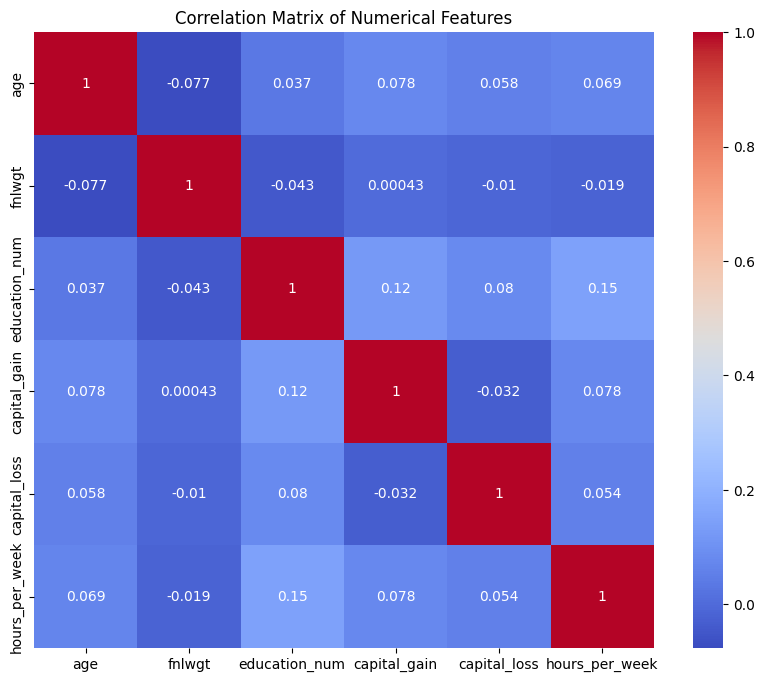

In [18]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [19]:
# PPS Analysis (Conceptual / Code if library available)
!pip install ppscore
import ppscore as pps
pps_matrix = pps.matrix(df_encoded[num_cols])
print("\nPPS Matrix (Top relationships):\n", pps_matrix[pps_matrix['ppscore'] > 0])


PPS Matrix (Top relationships):
                  x               y   ppscore            case  is_valid_score  \
0              age             age  1.000000  predict_itself            True   
7           fnlwgt          fnlwgt  1.000000  predict_itself            True   
12   education_num             age  0.016926      regression            True   
14   education_num   education_num  1.000000  predict_itself            True   
18    capital_gain             age  0.003296      regression            True   
20    capital_gain   education_num  0.012555      regression            True   
21    capital_gain    capital_gain  1.000000  predict_itself            True   
28    capital_loss    capital_loss  1.000000  predict_itself            True   
30  hours_per_week             age  0.002377      regression            True   
35  hours_per_week  hours_per_week  1.000000  predict_itself            True   

                 metric  baseline_score  model_score                    model  
0    